### Bull Call Spread: Comprehensive Summary

A **Bull Call Spread** is a bullish strategy constructed by buying a call option at a lower strike ($K_1$) and selling a call option at a higher strike ($K_2$) with the same expiration date.

---

#### 1. General Payoff Formula
At maturity ($T=0$), the payoff of the spread depends on the spot price ($S$) relative to the two strikes:

$$\text{Payoff} = \max(S - K_1, 0) - \max(S - K_2, 0)$$

| Spot Price ($S$) | Payoff |
| :--- | :--- |
| $S \le K_1$ | $0$ |
| $K_1 < S < K_2$ | $S - K_1$ |
| $S \ge K_2$ | $K_2 - K_1$ (Maximum Gain) |

---

#### 2. Black-Scholes Present Value (PV)
Before maturity ($T > 0$), the value of the spread is the difference between the two European call prices:

$$V_{\text{Spread}} = C(S, K_1, T, r, \sigma) - C(S, K_2, T, r, \sigma)$$

**Key Dynamics:**
* **Cap Level:** The maximum value is limited to the discounted strike difference: $(K_2 - K_1)e^{-rT}$.
* **Volatility ($\sigma$):** Increasing volatility flattens the "S-curve". It increases the value when the spot is below $K_1$ (Long Vega) but decreases the value when the spot is above $K_2$ (Short Vega).
* **Time Decay (Theta):** As $T \to 0$, the smooth curve converges toward the sharp, piecewise-linear payoff line.



---

#### 3. Synthetic Replication with Puts
Using **Put-Call Parity** ($C - P = S - K e^{-rT}$), a Call Spread can be replicated using Put options and cash:

$$\underbrace{C(K_1) - C(K_2)}_{\text{Bull Call Spread}} = \underbrace{P(K_1) - P(K_2)}_{\text{Put Spread}} + \underbrace{(K_2 - K_1)e^{-rT}}_{\text{Cash Adjustment}}$$

**Replication Strategy:**
* **Functional (Risk) Replication:** To replicate the **Greeks** ($\Delta, \Gamma, \nu$), simply trade a Put Spread (Buy $P_{K_1}$, Sell $P_{K_2}$).
* **Exact Payoff Replication:** To match the **absolute dollar payoff**, you must also hold the discounted cash difference $(K_2 - K_1)e^{-rT}$.

---

#### 4. Summary of Strategy Greeks
| Greek | Near $K_1$ (Lower) | Near $K_2$ (Higher) |
| :--- | :--- | :--- |
| **Delta ($\Delta$)** | Positive (Bullish) | Positive (Bullish) |
| **Gamma ($\Gamma$)** | Positive (Long) | Negative (Short) |
| **Vega ($\nu$)** | Positive (Long) | Negative (Short) |

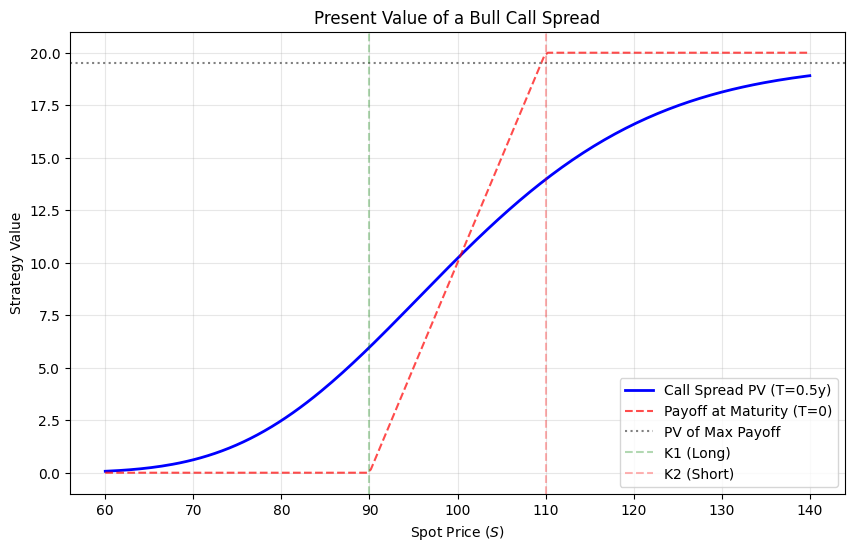

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def bs_call(S, K, T, r, sigma):
    if T <= 0: return np.maximum(S - K, 0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# Parameters
K1, K2 = 90, 110   # Strikes
r = 0.05           # Interest rate
sigma = 0.25       # Volatility
T = 0.5            # Time to maturity (6 months)
S_range = np.linspace(60, 140, 200)

# Calculate Present Value and Payoff
pv_spread = bs_call(S_range, K1, T, r, sigma) - bs_call(S_range, K2, T, r, sigma)
payoff_spread = np.maximum(S_range - K1, 0) - np.maximum(S_range - K2, 0)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(S_range, pv_spread, label=f'Call Spread PV (T={T}y)', color='blue', linewidth=2)
plt.plot(S_range, payoff_spread, 'r--', label='Payoff at Maturity (T=0)', alpha=0.7)

# Reference lines
plt.axhline(y=(K2-K1)*np.exp(-r*T), color='gray', linestyle=':', label='PV of Max Payoff')
plt.axvline(x=K1, color='green', linestyle='--', alpha=0.3, label='K1 (Long)')
plt.axvline(x=K2, color='red', linestyle='--', alpha=0.3, label='K2 (Short)')

plt.title('Present Value of a Bull Call Spread')
plt.xlabel('Spot Price ($S$)')
plt.ylabel('Strategy Value')gi
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Impact of Volatility on a Call Spread

The S-curve (sigmoid) of a call spread changes its slope based on implied volatility ($\sigma$):

1. **Lower Volatility ($\sigma \downarrow$):** The curve becomes **steeper**. The price reflects the payoff more closely because there is less uncertainty about the price staying in its current zone.
2. **Higher Volatility ($\sigma \uparrow$):** The curve becomes **flatter**. The price "bleeds" out into the wings because the probability of extreme moves (getting into the money or falling out of it) is higher.
3. **Max Value Ceiling:** Regardless of volatility, the maximum present value is always capped at $(K_2 - K_1)e^{-rT}$ due to the time value of money.

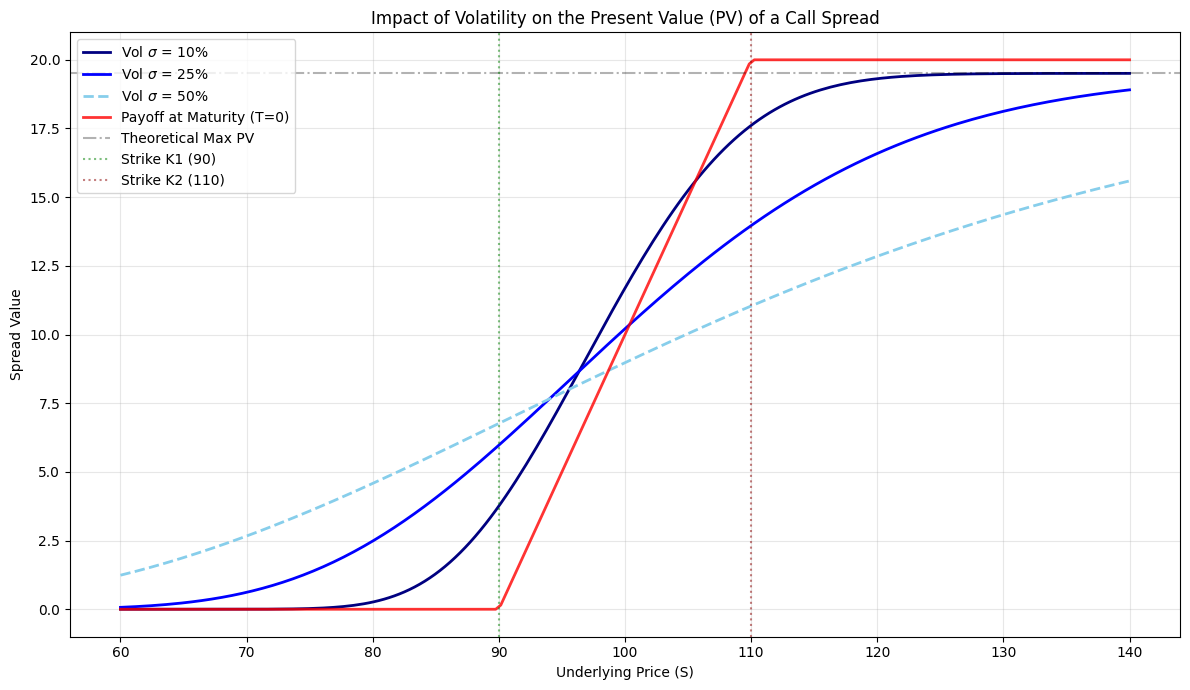

In [3]:
# --- Step 1: Spread Parameters ---
K1, K2 = 90, 110    # Strikes (Long K1, Short K2)
r = 0.05            # Risk-free rate (5%)
T = 0.5             # Time to maturity (6 months)
S_range = np.linspace(60, 140, 200)

# Volatility Scenarios
vols = [0.10, 0.25, 0.50]  # Low, Base, High
colors = ['navy', 'blue', 'skyblue']
styles = ['-', '-', '--']

# --- Step 2: Calculation and Plotting ---
plt.figure(figsize=(12, 7))

for sigma, color, style in zip(vols, colors, styles):
    # Calculate Spread PV: Call(K1) - Call(K2)
    pv_spread = [bs_call(S, K1, T, r, sigma) - 
                 bs_call(S, K2, T, r, sigma) for S in S_range]
    
    plt.plot(S_range, pv_spread, label=f'Vol $\sigma$ = {sigma:.0%}', 
             color=color, lw=2, ls=style)

# Add Payoff at maturity (T=0)
payoff = np.maximum(S_range - K1, 0) - np.maximum(S_range - K2, 0)
plt.plot(S_range, payoff, label='Payoff at Maturity (T=0)', 
         color='red', lw=2, alpha=0.8)

# --- Step 3: Visual Indicators ---
# Theoretical Cap (Discounted max value)
max_val_pv = (K2 - K1) * np.exp(-r * T)
plt.axhline(y=max_val_pv, color='black', ls='-.', alpha=0.3, label='Theoretical Max PV')

# Strike Lines
plt.axvline(x=K1, color='green', ls=':', alpha=0.5, label=f'Strike K1 ({K1})')
plt.axvline(x=K2, color='darkred', ls=':', alpha=0.5, label=f'Strike K2 ({K2})')

# Formatting
plt.title('Impact of Volatility on the Present Value (PV) of a Call Spread')
plt.xlabel('Underlying Price (S)')
plt.ylabel('Spread Value')
plt.legend(loc='upper left', frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()